In [ ]:
# Customer Segmentation Using Clustering Algorithms

This project explores how clustering algorithms can be used to segment customers based on their demographic and purchasing characteristics.

Customer segmentation is an important technique in marketing and business analytics. By identifying groups of customers with similar behaviour,
companies can design more targeted marketing strategies and improve customer satisfaction.

In this project we analyze a customer dataset and apply clustering algorithms to discover meaningful customer segments.

In [ ]:
## Research Question

How can clustering algorithms be used to identify meaningful customer segments based on purchasing behaviour and demographic data?

In [ ]:
## Project Objectives

The main objectives of this project are:

- To analyze a customer dataset
- To explore the relationships between different customer attributes
- To apply clustering algorithms in order to group similar customers
- To visualize the discovered customer segments
- To interpret the results from a business perspective

In [ ]:
## Dataset Description

The dataset used in this project contains information about mall customers.

Each record represents a customer and includes several attributes describing their demographic and purchasing behaviour.

The main features of the dataset include:

- CustomerID – Unique identifier for each customer
- Gender – Gender of the customer
- Age – Age of the customer
- Annual Income (k$) – Annual income of the customer
- Spending Score (1–100) – A score assigned by the mall based on customer behaviour and spending patterns

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
## Loading the Dataset

In this step we load the dataset and examine the first few rows in order to understand the structure of the data.
Code

In [2]:
df = pd.read_csv(
    "Segmentation_Summer Seasonal.dat",
    sep="\t",
    encoding="cp1251"
)

df.head()

,Customer,City,Channel,Segment,Urbanicity,Traffic,Traffic Index,Equipment (Y/N),# of doors,Sales 2025 CS
0,10000,ЗЛАТНИ ПЯСЪЦИ,Hotels,Seasonal High Traffic,3,"30422,86",High,Yes,6,0
1,10001,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"58764,25",High,Yes,0,0
2,10002,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"32763,5",High,Yes,0,0
3,10003,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal Low/Mid Traffic,1,"23147,5",Medium,Yes,0,0
4,10004,СЛЪНЧЕВ БРЯГ,Qsr,Seasonal High Traffic,1,"34339,25",High,Yes,2,56


In [3]:
df["Traffic"] = df["Traffic"].astype(str).str.replace(",", ".").astype(float)

In [ ]:
## Exploratory Data Analysis

Before applying clustering algorithms, it is important to explore the dataset and understand its structure.

In this section we examine:

- The size of the dataset
- Basic statistics of the features
- Distribution of variables
- Relationships between variables

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer         5574 non-null   int64  
 1   City             5574 non-null   object 
 2   Channel          5574 non-null   object 
 3   Segment          5574 non-null   object 
 4   Urbanicity       5574 non-null   int64  
 5   Traffic          5574 non-null   float64
 6   Traffic Index    5574 non-null   object 
 7   Equipment (Y/N)  5574 non-null   object 
 8   # of doors       5574 non-null   object 
 9   Sales 2025 CS    5574 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 435.6+ KB


,Customer,Urbanicity,Traffic
count,5574.000000,5574.000000,5574.000000
mean,12786.500000,4.058306,20450.364615
std,1609.219531,2.060891,15406.316568
min,10000.000000,1.000000,10.540000
25%,11393.250000,3.000000,10069.115000
50%,12786.500000,4.000000,17299.400000
75%,14179.750000,5.000000,28627.760000
max,15573.000000,10.000000,151311.830000


In [ ]:
## Data Preprocessing

Clustering algorithms work best when the data is properly prepared.

In this step we select the relevant features and scale the data.

Feature scaling is important because clustering algorithms such as K-Means rely on distance calculations. 
If features have different scales, some variables may dominate the clustering process.

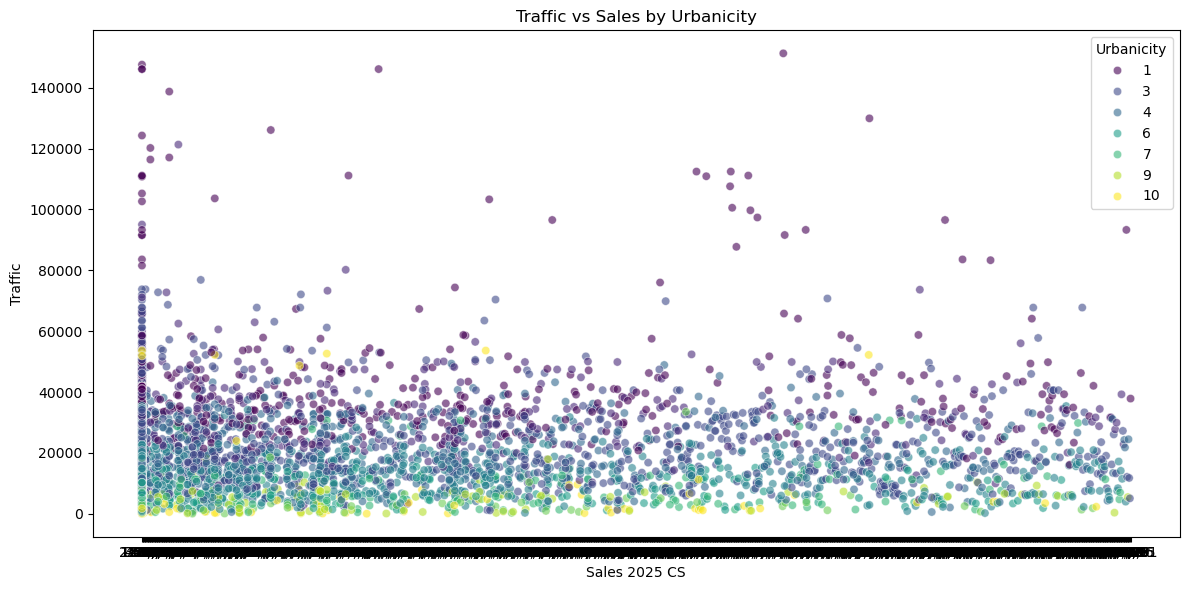

In [9]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x=df["Sales 2025 CS"],
    y=df["Traffic"],
    hue=df["Urbanicity"],
    palette="viridis",
    alpha=0.6
)

plt.title("Traffic vs Sales by Urbanicity")
plt.xlabel("Sales 2025 CS")
plt.ylabel("Traffic")

plt.tight_layout()
plt.show()

In [7]:
features = [
    "Urbanicity",
    "Traffic",
    "# of doors",
    "Sales 2025 CS"
]

X = df[features]

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

ValueError: could not convert string to float: '1,5'

In [9]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

NameError: name 'X_scaled' is not defined

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

NameError: name 'X_scaled' is not defined

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Traffic"],
    y=df["Sales 2025 CS"],
    hue=df["Cluster"],
    palette="viridis"
)

plt.title("Location Segmentation")
plt.show()

KeyError: 'Cluster'

<Figure size 800x600 with 0 Axes>

In [ ]:
## Clustering Algorithms

Clustering is an unsupervised machine learning technique used to group similar data points together.

In this project we use the K-Means clustering algorithm.

The main idea behind K-Means is to divide the dataset into a predefined number of clusters. Each data point is assigned to the nearest cluster centroid.

The algorithm works iteratively:

1. Initialize cluster centroids
2. Assign each data point to the nearest centroid
3. Recalculate centroids based on cluster members
4. Repeat until convergence

In [ ]:
## Mathematical Formulation of K-Means

The objective of the K-Means algorithm is to minimize the within-cluster sum of squares (WCSS).

The optimization problem can be written as:

J = Σ Σ ||x - μ||²

Where:

x represents a data point  
μ represents the centroid of a cluster  

The algorithm tries to minimize the distance between data points and their corresponding cluster centroids.

In [ ]:
## Determining the Optimal Number of Clusters

Choosing the correct number of clusters is an important step in clustering analysis.

In this project we use the **Elbow Method**. This method calculates the within-cluster sum of squares (WCSS) for different values of k.

The optimal number of clusters is usually found at the point where the decrease in WCSS starts to slow down.

In [6]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

NameError: name 'X_scaled' is not defined

In [ ]:
## Clustering Results

After applying the K-Means algorithm, each customer is assigned to a cluster.

We visualize the clusters using a scatter plot of Annual Income and Spending Score.

This allows us to see how customers are grouped according to their spending behaviour.

In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending Score (1-100)"],
    hue=df["Cluster"],
    palette="viridis"
)

plt.title("Customer Segments")
plt.show()

NameError: name 'X_scaled' is not defined

In [ ]:
## Business Interpretation

The clustering analysis reveals several distinct customer groups.

For example:

- Customers with high income and high spending scores may represent VIP customers.
- Customers with high income but low spending scores may represent potential customers who could be targeted with marketing campaigns.
- Customers with low income and low spending scores may represent budget customers.

These insights could help businesses design targeted marketing strategies and improve customer engagement.


In [ ]:
## Conclusion

In this project we applied clustering algorithms to perform customer segmentation.

The K-Means algorithm successfully identified several groups of customers with similar characteristics. These clusters provide useful insights into customer behaviour and can help businesses make data-driven marketing decisions.

Future work could include testing other clustering algorithms, incorporating additional features, or applying the model to larger datasets.